In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/Titanic.csv')
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
847,848,0,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C
746,747,0,3,"Abbott, Mr. Rossmore Edward",male,16.0,1,1,C.A. 2673,20.2500,NaN,S
315,316,1,3,"Nilsson, Miss. Helmina Josefina",female,26.0,0,0,347470,7.8542,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [32]:
df['Survived'].value_counts()

Survived
0    512
1    263
Name: count, dtype: int64

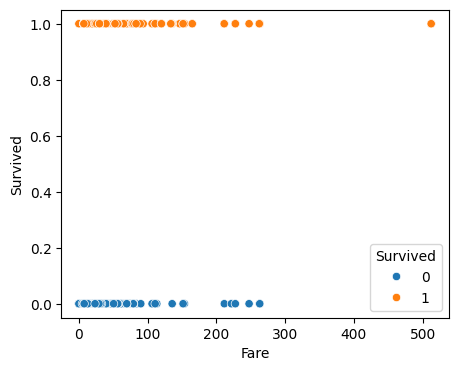

In [6]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x = 'Fare', y = 'Survived', hue = 'Survived', data = df)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

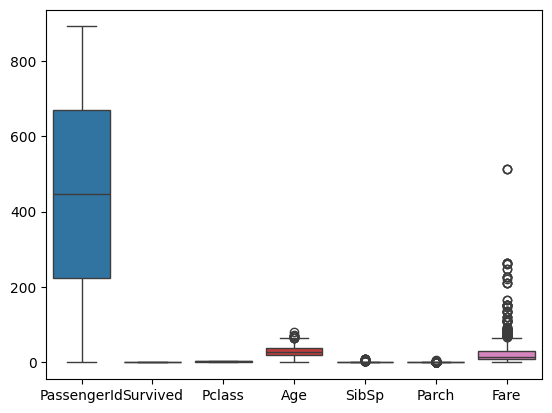

In [7]:
sns.boxplot(df)
plt.show

In [8]:
def drop_outliers(df, colums_name):
  iqr = 1.5 * (np.percentile(df[colums_name], 75) - np.percentile(df[colums_name], 25))
  df.drop(df[df[colums_name] > (iqr + np.percentile(df[colums_name], 75))].index, inplace = True)
  df.drop(df[df[colums_name] < (np.percentile(df[colums_name], 25) - iqr)].index, inplace = True)

drop_outliers(df, 'Fare')

<function matplotlib.pyplot.show(close=None, block=None)>

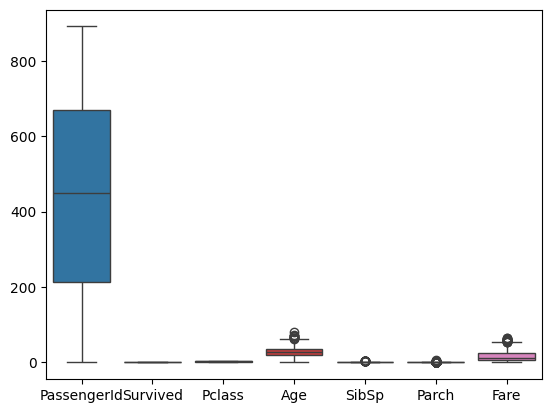

In [9]:
sns.boxplot(df)
plt.show

In [10]:
y = df['Survived']

In [11]:
X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis = 1)

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  775 non-null    int64  
 1   Sex     775 non-null    object 
 2   Age     613 non-null    float64
 3   SibSp   775 non-null    int64  
 4   Parch   775 non-null    int64  
 5   Fare    775 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 42.4+ KB


In [13]:
X['Age'].median()

28.0

In [14]:
X['Age'] = X['Age'].fillna(X['Age'].median())

In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  775 non-null    int64  
 1   Sex     775 non-null    object 
 2   Age     775 non-null    float64
 3   SibSp   775 non-null    int64  
 4   Parch   775 non-null    int64  
 5   Fare    775 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 42.4+ KB


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])

In [17]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
2,3,0,26.0,0,0,7.9250
3,1,0,35.0,1,0,53.1000
4,3,1,35.0,0,0,8.0500
5,3,1,28.0,0,0,8.4583
...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000
887,1,0,19.0,0,0,30.0000
888,3,0,28.0,1,2,23.4500
889,1,1,26.0,0,0,30.0000


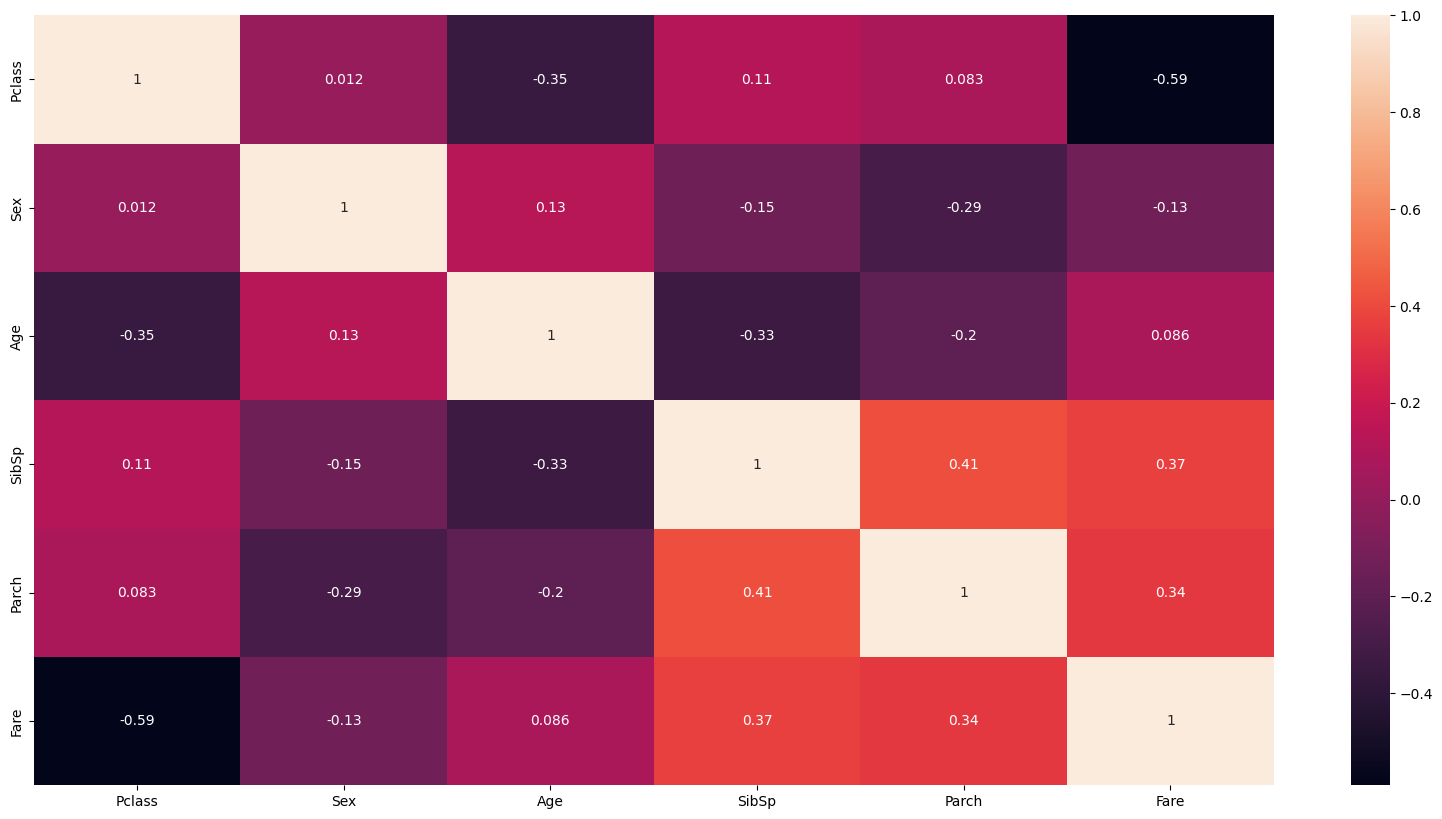

In [18]:
plt.figure(figsize=(20,10))
sns.heatmap(X.corr(), annot=True)
plt.show()

<Figure size 750x350 with 0 Axes>

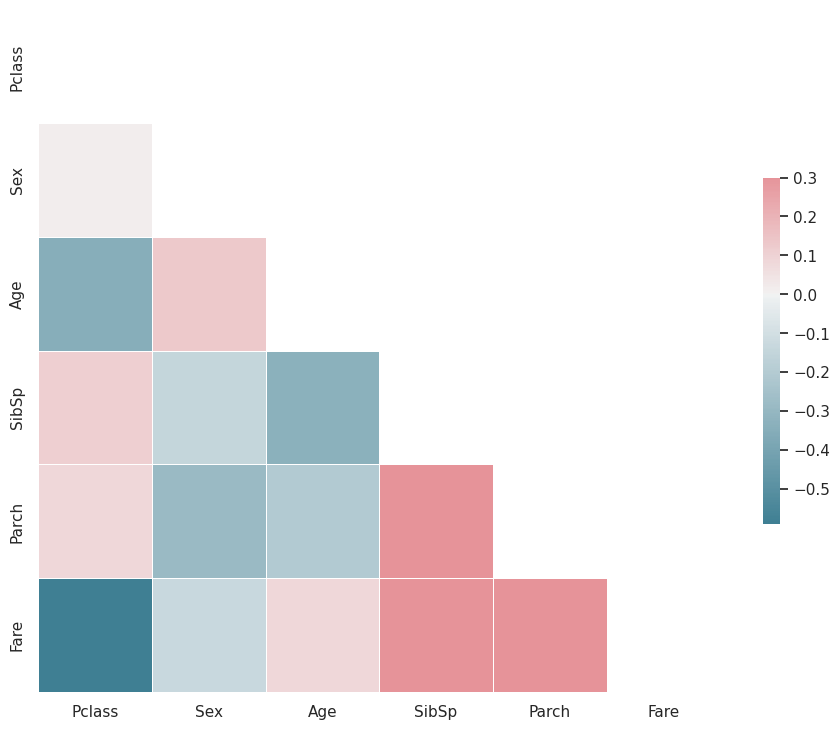

In [19]:
plt.figure(figsize=(7.5, 3.5))
corr = X.corr()
sns.set(style='white')
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scalled = sc.fit_transform(X)

In [21]:
X_scalled

array([[ 0.70852824,  0.67787193, -0.5283213 ,  0.62560563, -0.43371803,
        -0.77911707],
       [ 0.70852824, -1.4752049 , -0.21518215, -0.48642273, -0.43371803,
        -0.7293725 ],
       [-2.01658037, -1.4752049 ,  0.48938093,  0.62560563, -0.43371803,
         2.59982835],
       ...,
       [ 0.70852824, -1.4752049 , -0.05861258,  0.62560563,  2.11273252,
         0.41475242],
       [-2.01658037,  0.67787193, -0.21518215, -0.48642273, -0.43371803,
         0.89745891],
       [ 0.70852824,  0.67787193,  0.25452657, -0.48642273, -0.43371803,
        -0.74226924]])

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scalled, y, test_size = 0.2, random_state = 42)

In [25]:
from sklearn.svm import SVC
svc = SVC()
svm = svc.fit(X_train, y_train)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [33]:
y_pred_train = svm.predict(X_train)
accuracy_train = accuracy_score(y_pred_train, y_train)
f1_train = f1_score(y_pred_train, y_train)

In [34]:
print('Train Data of NB: ','\n')
print('Accuracy on Train Data: ', accuracy_train, '\n')
print('F1_Score on Train Data: ', f1_train, '\n')
print('Classification Report on Train Data: ', '\n', '\n', classification_report(y_train, y_pred_train, target_names=[' Not Survived','Survived']))

Train Data of NB:  

Accuracy on Train Data:  0.8370967741935483 

F1_Score on Train Data:  0.7362924281984334 

Classification Report on Train Data:  
 
                precision    recall  f1-score   support

 Not Survived       0.86      0.91      0.88       417
     Survived       0.78      0.69      0.74       203

     accuracy                           0.84       620
    macro avg       0.82      0.80      0.81       620
 weighted avg       0.83      0.84      0.83       620



In [35]:
y_pred_test = svm.predict(X_test)
accuracy_test = accuracy_score(y_pred_test, y_test)
f1_test = f1_score(y_pred_test, y_test)

In [36]:
print('test Data of NB: ','\n')
print('Accuracy on test Data: ', accuracy_test, '\n')
print('F1_Score on test Data: ', f1_test, '\n')
print('Classification Report on test Data: ', '\n', '\n', classification_report(y_test, y_pred_test, target_names=[' Not Survived','Survived']))

test Data of NB:  

Accuracy on test Data:  0.7806451612903226 

F1_Score on test Data:  0.6909090909090909 

Classification Report on test Data:  
 
                precision    recall  f1-score   support

 Not Survived       0.79      0.87      0.83        95
     Survived       0.76      0.63      0.69        60

     accuracy                           0.78       155
    macro avg       0.78      0.75      0.76       155
 weighted avg       0.78      0.78      0.78       155



In [38]:
c_train = confusion_matrix(y_pred_train, y_train)
c_test  = confusion_matrix(y_pred_test, y_test)

print('Confusion Matrix on Train Data: ','\n', c_train, '\n')
print('Confusion Matrix on Test  Data: ', '\n', c_test)

Confusion Matrix on Train Data:  
 [[378  62]
 [ 39 141]] 

Confusion Matrix on Test  Data:  
 [[83 22]
 [12 38]]


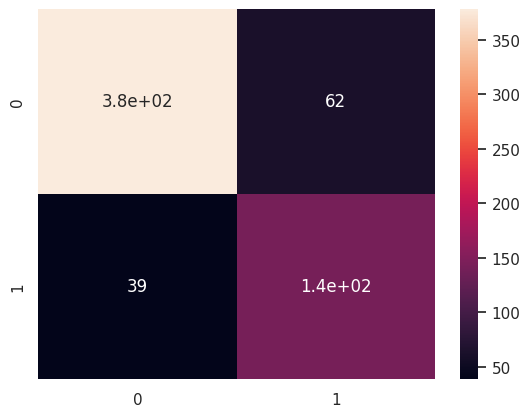

In [39]:
sns.heatmap(c_train, annot=True)
plt.show()

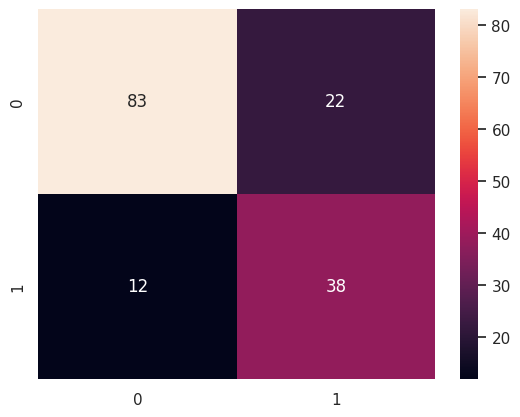

In [40]:
sns.heatmap(c_test, annot=True)
plt.show()